# Análise de Vendas de uma Loja

## Objetivo

Este projeto tem como objetivo analisar dados fictícios de vendas de uma loja, utilizando SQL e Python.

A análise busca identificar informações como:

- faturamento total;
- faturamento por produto;
- faturamento por cidade;
- faturamento por categoria;
- quantidade de produtos vendidos;
- ticket médio;
- evolução do faturamento ao longo dos meses.

## Tecnologias utilizadas

- Python
- SQL
- SQLite
- Pandas
- Matplotlib
- Google Colab

> **Observação:** os dados utilizados neste projeto são fictícios e foram criados exclusivamente para fins de estudo e portfólio.

In [2]:
import sqlite3

conexao = sqlite3.connect("loja.db")
cursor = conexao.cursor()

## Estrutura do banco de dados

Para realizar a análise, foi criado um banco de dados SQLite com três tabelas principais:

- **clientes:** informações dos clientes, como nome e cidade.
- **produtos:** informações dos produtos, como categoria e preço.
- **pedidos:** registros das vendas, relacionando clientes e produtos, além da quantidade, data e valor do pedido.

As tabelas foram relacionadas por meio dos identificadores (`id`), permitindo realizar consultas utilizando `JOIN`.

In [3]:
cursor.execute("""
CREATE TABLE clientes (
    id INTEGER PRIMARY KEY,
    nome TEXT,
    cidade TEXT
)
""")

conexao.commit()

In [4]:
cursor.executemany("""
INSERT INTO clientes (id, nome, cidade)
VALUES (?, ?, ?)
""", [
    (1, "Ana", "São Paulo"),
    (2, "João", "Curitiba"),
    (3, "Maria", "São Paulo"),
    (4, "Pedro", "Londrina"),
    (5, "Eduarda", "Curitiba"),
    (6, "Felipe", "Londrina"),
    (7, "Gabriela", "São Paulo"),
    (8, "Henrique", "Curitiba"),
    (9, "Isabela", "Londrina"),
    (10, "Lucas", "São Paulo")
])

conexao.commit()

## Estrutura do banco de dados

Para realizar a análise, foi criado um banco de dados SQLite com três tabelas principais:

- **clientes:** informações dos clientes, como nome e cidade.
- **produtos:** informações dos produtos, como categoria e preço.
- **pedidos:** registros das vendas, relacionando clientes e produtos, além da quantidade, data e valor do pedido.

As tabelas foram relacionadas por meio dos identificadores (`id`), permitindo realizar consultas utilizando `JOIN`.

In [5]:
cursor.execute("""
SELECT *
FROM clientes;
""")

resultado = cursor.fetchall()

resultado

[(1, 'Ana', 'São Paulo'),
 (2, 'João', 'Curitiba'),
 (3, 'Maria', 'São Paulo'),
 (4, 'Pedro', 'Londrina'),
 (5, 'Eduarda', 'Curitiba'),
 (6, 'Felipe', 'Londrina'),
 (7, 'Gabriela', 'São Paulo'),
 (8, 'Henrique', 'Curitiba'),
 (9, 'Isabela', 'Londrina'),
 (10, 'Lucas', 'São Paulo')]

In [6]:
cursor.execute("""
CREATE TABLE produtos (
    id INTEGER PRIMARY KEY,
    produto TEXT,
    categoria TEXT,
    preco REAL
)
""")

conexao.commit()

In [7]:
cursor.executemany("""
INSERT INTO produtos (id, produto, categoria, preco)
VALUES (?, ?, ?, ?)
""", [
    (1, "Notebook", "Eletrônicos", 3500),
    (2, "Mouse", "Eletrônicos", 80),
    (3, "Teclado", "Eletrônicos", 150),
    (4, "Cadeira", "Móveis", 900),
    (5, "Mesa", "Móveis", 700),
    (6, "Fone de ouvido", "Eletrônicos", 250),
    (7, "Mochila", "Acessórios", 180),
    (8, "Webcam", "Eletrônicos", 300)
])

conexao.commit()

In [8]:
cursor.execute("""
CREATE TABLE pedidos (
    id INTEGER PRIMARY KEY,
    cliente_id INTEGER,
    produto_id INTEGER,
    quantidade INTEGER,
    data TEXT,
    valor REAL
)
""")

conexao.commit()

In [9]:
cursor.executemany("""
INSERT INTO pedidos (id, cliente_id, produto_id, quantidade, data, valor)
VALUES (?, ?, ?, ?, ?, ?)
""", [
    (1, 1, 1, 1, "2026-01-10", 3500),
    (2, 2, 2, 2, "2026-01-12", 160),
    (3, 3, 3, 1, "2026-01-15", 150),
    (4, 4, 4, 1, "2026-01-18", 900),
    (5, 5, 5, 1, "2026-01-20", 700),
    (6, 6, 6, 2, "2026-01-22", 500),
    (7, 7, 7, 1, "2026-01-25", 180),
    (8, 8, 8, 1, "2026-01-28", 300),
    (9, 9, 2, 3, "2026-02-02", 240),
    (10, 10, 3, 2, "2026-02-05", 300),
    (11, 1, 6, 1, "2026-02-08", 250),
    (12, 2, 7, 2, "2026-02-10", 360),
    (13, 3, 1, 1, "2026-02-15", 3500),
    (14, 4, 8, 2, "2026-02-18", 600),
    (15, 5, 4, 1, "2026-02-20", 900)
])

conexao.commit()

In [10]:
cursor.execute("""
SELECT clientes.nome, produtos.produto, pedidos.quantidade, pedidos.valor
FROM pedidos
JOIN clientes
    ON pedidos.cliente_id = clientes.id
JOIN produtos
    ON pedidos.produto_id = produtos.id;
""")

resultado = cursor.fetchall()

resultado

[('Ana', 'Notebook', 1, 3500.0),
 ('João', 'Mouse', 2, 160.0),
 ('Maria', 'Teclado', 1, 150.0),
 ('Pedro', 'Cadeira', 1, 900.0),
 ('Eduarda', 'Mesa', 1, 700.0),
 ('Felipe', 'Fone de ouvido', 2, 500.0),
 ('Gabriela', 'Mochila', 1, 180.0),
 ('Henrique', 'Webcam', 1, 300.0),
 ('Isabela', 'Mouse', 3, 240.0),
 ('Lucas', 'Teclado', 2, 300.0),
 ('Ana', 'Fone de ouvido', 1, 250.0),
 ('João', 'Mochila', 2, 360.0),
 ('Maria', 'Notebook', 1, 3500.0),
 ('Pedro', 'Webcam', 2, 600.0),
 ('Eduarda', 'Cadeira', 1, 900.0)]

## Análise do faturamento

### Faturamento total

Nesta etapa, foi calculado o faturamento total da loja a partir da soma dos valores dos pedidos.

In [12]:
cursor.execute("""
SELECT SUM(valor) AS faturamento_total
FROM pedidos;
""")

resultado = cursor.fetchall()

resultado

[(12540.0,)]

## Faturamento por produto

Nesta análise, foi calculado o faturamento gerado por cada produto.

Os resultados foram agrupados por produto e organizados do maior para o menor faturamento.

In [13]:
cursor.execute("""
SELECT
    produtos.produto,
    SUM(pedidos.valor) AS faturamento
FROM pedidos
JOIN produtos
    ON pedidos.produto_id = produtos.id
GROUP BY produtos.produto
ORDER BY faturamento DESC;
""")

resultado = cursor.fetchall()

resultado

[('Notebook', 7000.0),
 ('Cadeira', 1800.0),
 ('Webcam', 900.0),
 ('Fone de ouvido', 750.0),
 ('Mesa', 700.0),
 ('Mochila', 540.0),
 ('Teclado', 450.0),
 ('Mouse', 400.0)]

## Faturamento por cidade

Nesta análise, foi calculado o faturamento gerado pelos clientes de cada cidade.

Os resultados foram agrupados por cidade e organizados do maior para o menor faturamento.

In [14]:
cursor.execute("""
SELECT
    clientes.cidade,
    SUM(pedidos.valor) AS faturamento
FROM pedidos
JOIN clientes
    ON pedidos.cliente_id = clientes.id
GROUP BY clientes.cidade
ORDER BY faturamento DESC;
""")

resultado = cursor.fetchall()

resultado

[('São Paulo', 7880.0), ('Curitiba', 2420.0), ('Londrina', 2240.0)]

## Faturamento por cliente

Nesta análise, foi calculado quanto cada cliente gastou no período analisado.

Os resultados foram agrupados por cliente e organizados do maior para o menor valor gasto.

In [15]:
cursor.execute("""
SELECT
    clientes.nome,
    SUM(pedidos.valor) AS total_gasto
FROM pedidos
JOIN clientes
    ON pedidos.cliente_id = clientes.id
GROUP BY clientes.nome
ORDER BY total_gasto DESC;
""")

resultado = cursor.fetchall()

resultado

[('Ana', 3750.0),
 ('Maria', 3650.0),
 ('Eduarda', 1600.0),
 ('Pedro', 1500.0),
 ('João', 520.0),
 ('Felipe', 500.0),
 ('Lucas', 300.0),
 ('Henrique', 300.0),
 ('Isabela', 240.0),
 ('Gabriela', 180.0)]

## Ticket médio

O ticket médio representa o valor médio de cada pedido realizado na loja.

Nesta análise, foi utilizada a função `AVG()` para calcular a média dos valores dos pedidos.

In [16]:
cursor.execute("""
SELECT
    AVG(valor) AS ticket_medio
FROM pedidos;
""")

resultado = cursor.fetchall()

resultado

[(836.0,)]

## Quantidade de produtos vendidos

Nesta análise, foi calculada a quantidade total de unidades vendidas de cada produto.

Os resultados foram agrupados por produto e organizados da maior para a menor quantidade vendida.

In [17]:
cursor.execute("""
SELECT
    produtos.produto,
    SUM(pedidos.quantidade) AS unidades_vendidas
FROM pedidos
JOIN produtos
    ON pedidos.produto_id = produtos.id
GROUP BY produtos.produto
ORDER BY unidades_vendidas DESC;
""")

resultado = cursor.fetchall()

resultado

[('Mouse', 5),
 ('Webcam', 3),
 ('Teclado', 3),
 ('Mochila', 3),
 ('Fone de ouvido', 3),
 ('Notebook', 2),
 ('Cadeira', 2),
 ('Mesa', 1)]

## Faturamento por categoria

Nesta análise, foi calculado o faturamento total de cada categoria de produtos.

Os resultados foram agrupados por categoria e organizados do maior para o menor faturamento.

In [18]:
cursor.execute("""
SELECT
    produtos.categoria,
    SUM(pedidos.valor) AS faturamento
FROM pedidos
JOIN produtos
    ON pedidos.produto_id = produtos.id
GROUP BY produtos.categoria
ORDER BY faturamento DESC;
""")

resultado = cursor.fetchall()

resultado

[('Eletrônicos', 9500.0), ('Móveis', 2500.0), ('Acessórios', 540.0)]

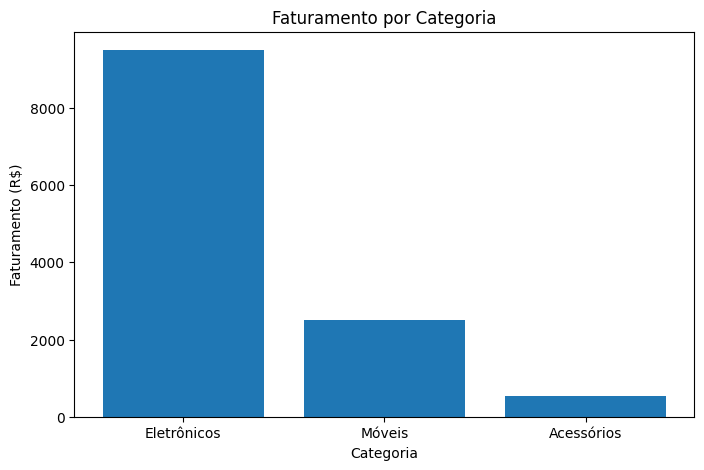

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

dados = {
    "Categoria": ["Eletrônicos", "Móveis", "Acessórios"],
    "Faturamento": [9500, 2500, 540]
}

df_categorias = pd.DataFrame(dados)

plt.figure(figsize=(8, 5))

plt.bar(df_categorias["Categoria"], df_categorias["Faturamento"])

plt.title("Faturamento por Categoria")
plt.xlabel("Categoria")
plt.ylabel("Faturamento (R$)")

plt.show()

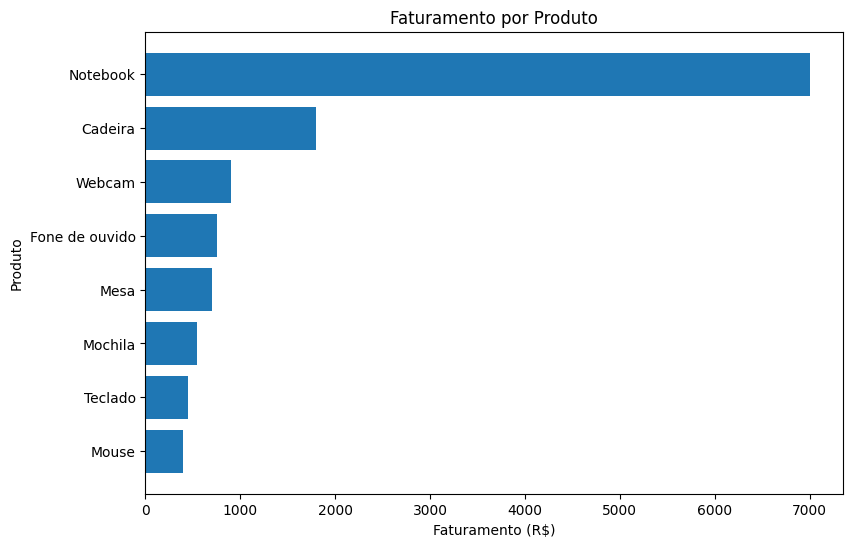

In [20]:
dados = {
    "Produto": [
        "Notebook",
        "Cadeira",
        "Webcam",
        "Fone de ouvido",
        "Mesa",
        "Mochila",
        "Teclado",
        "Mouse"
    ],
    "Faturamento": [
        7000,
        1800,
        900,
        750,
        700,
        540,
        450,
        400
    ]
}

df_produtos = pd.DataFrame(dados)

df_produtos = df_produtos.sort_values(
    "Faturamento",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    df_produtos["Produto"],
    df_produtos["Faturamento"]
)

plt.title("Faturamento por Produto")
plt.xlabel("Faturamento (R$)")
plt.ylabel("Produto")

plt.show()

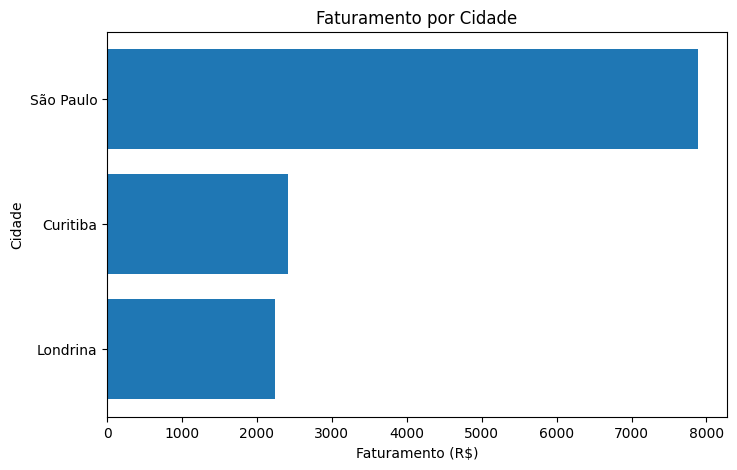

In [21]:
dados = {
    "Cidade": ["São Paulo", "Curitiba", "Londrina"],
    "Faturamento": [7880, 2420, 2240]
}

df_cidades = pd.DataFrame(dados)

df_cidades = df_cidades.sort_values(
    "Faturamento",
    ascending=True
)

plt.figure(figsize=(8, 5))

plt.barh(
    df_cidades["Cidade"],
    df_cidades["Faturamento"]
)

plt.title("Faturamento por Cidade")
plt.xlabel("Faturamento (R$)")
plt.ylabel("Cidade")

plt.show()

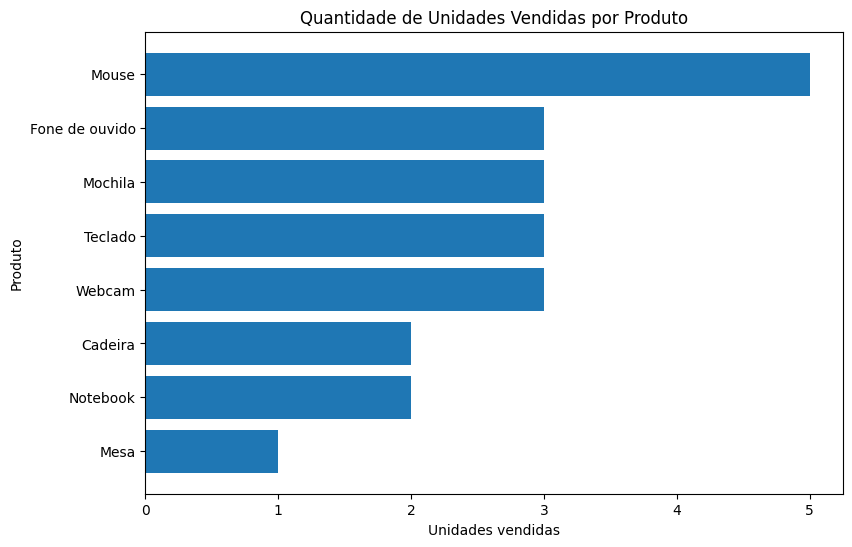

In [22]:
dados = {
    "Produto": [
        "Mouse",
        "Webcam",
        "Teclado",
        "Mochila",
        "Fone de ouvido",
        "Notebook",
        "Cadeira",
        "Mesa"
    ],
    "Unidades vendidas": [5, 3, 3, 3, 3, 2, 2, 1]
}

df_quantidade = pd.DataFrame(dados)

df_quantidade = df_quantidade.sort_values(
    "Unidades vendidas",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    df_quantidade["Produto"],
    df_quantidade["Unidades vendidas"]
)

plt.title("Quantidade de Unidades Vendidas por Produto")
plt.xlabel("Unidades vendidas")
plt.ylabel("Produto")

plt.show()

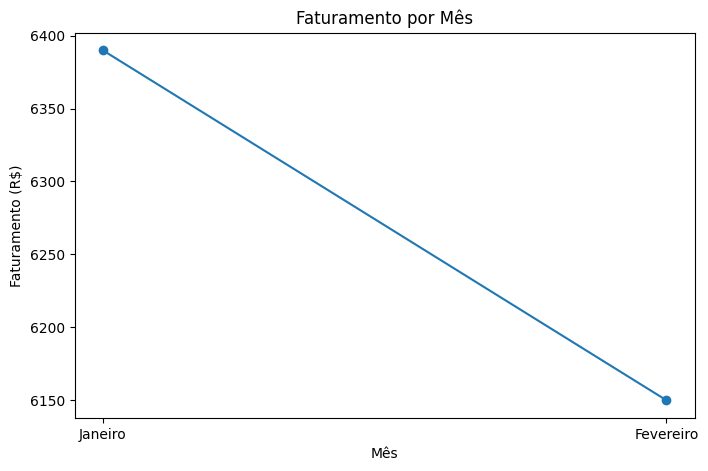

In [23]:
dados = {
    "Mês": ["Janeiro", "Fevereiro"],
    "Faturamento": [6390, 6150]
}

df_mensal = pd.DataFrame(dados)

plt.figure(figsize=(8, 5))

plt.plot(
    df_mensal["Mês"],
    df_mensal["Faturamento"],
    marker="o"
)

plt.title("Faturamento por Mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")

plt.show()

# Conclusões

A análise dos dados de vendas permitiu identificar alguns dos principais resultados da loja.

- O faturamento total no período analisado foi de **R$ 12.540,00**.
- O ticket médio por pedido foi de **R$ 836,00**.
- A categoria de **Eletrônicos** apresentou o maior faturamento, com **R$ 9.500,00**.
- O **Notebook** foi o produto com maior faturamento, gerando **R$ 7.000,00**.
- O **Mouse** foi o produto com maior quantidade de unidades vendidas, com **5 unidades**.
- **São Paulo** apresentou o maior faturamento entre as cidades analisadas, com **R$ 7.880,00**.
- O faturamento foi de **R$ 6.390,00 em janeiro** e **R$ 6.150,00 em fevereiro**.

## Principais insights

Um dos principais insights identificados foi que o produto com maior quantidade de unidades vendidas não foi necessariamente o produto com maior faturamento.

O **Mouse** vendeu mais unidades, enquanto o **Notebook** gerou o maior faturamento.

Como os dados utilizados neste projeto são fictícios, os resultados têm finalidade exclusivamente educacional e demonstrativa.